In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import numpy as np
import os

### Just Policy

In [2]:
# 1. Load Data
file_path = '../GradientInformation/experiment_results_cls_multi_oracle_False_samples_1000_date_2026-03-10.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"File {file_path} not found. Please ensure the experiment script has run.")
    # Create a dummy df structure for demonstration if file missing|
    df = pd.DataFrame(columns=['sample_idx', 'method', 'mh_enabled', 'trajectory', 'accuracy_pct'])


In [3]:
# 2. Preprocessing Trajectories
# We need to expand the 'trajectory' column which contains lists of dicts
expanded_rows = []

for idx, row in df.iterrows():
    if isinstance(row['trajectory'], str):
        try:
            traj_list = ast.literal_eval(row['trajectory'])
        except:
            continue
            
        method_label = row['method'].replace('_', ' ').title()
        mh_label = "With MH" if row['mh_enabled'] else "No MH"
        
        for step_data in traj_list:
            expanded_rows.append({
                "Method": method_label,
                "Sampling": mh_label,
                "Step": step_data['step'],
                # Note the 'avg_' prefix here which is different from previous single-token code
                "Avg L2 Distance": step_data.get('avg_l2_distance'), 
                "Avg KL Divergence": step_data.get('avg_kl_divergence'),
                "Entropy": step_data.get('entropy', 0)
            })

traj_df = pd.DataFrame(expanded_rows)


In [4]:
traj_df.head(2)

,Method,Sampling,Step,Avg L2 Distance,Avg KL Divergence,Entropy
0,Policy,With MH,0,0.692743,8.121155,0.0
1,Policy,With MH,1,0.692743,8.121155,0.0


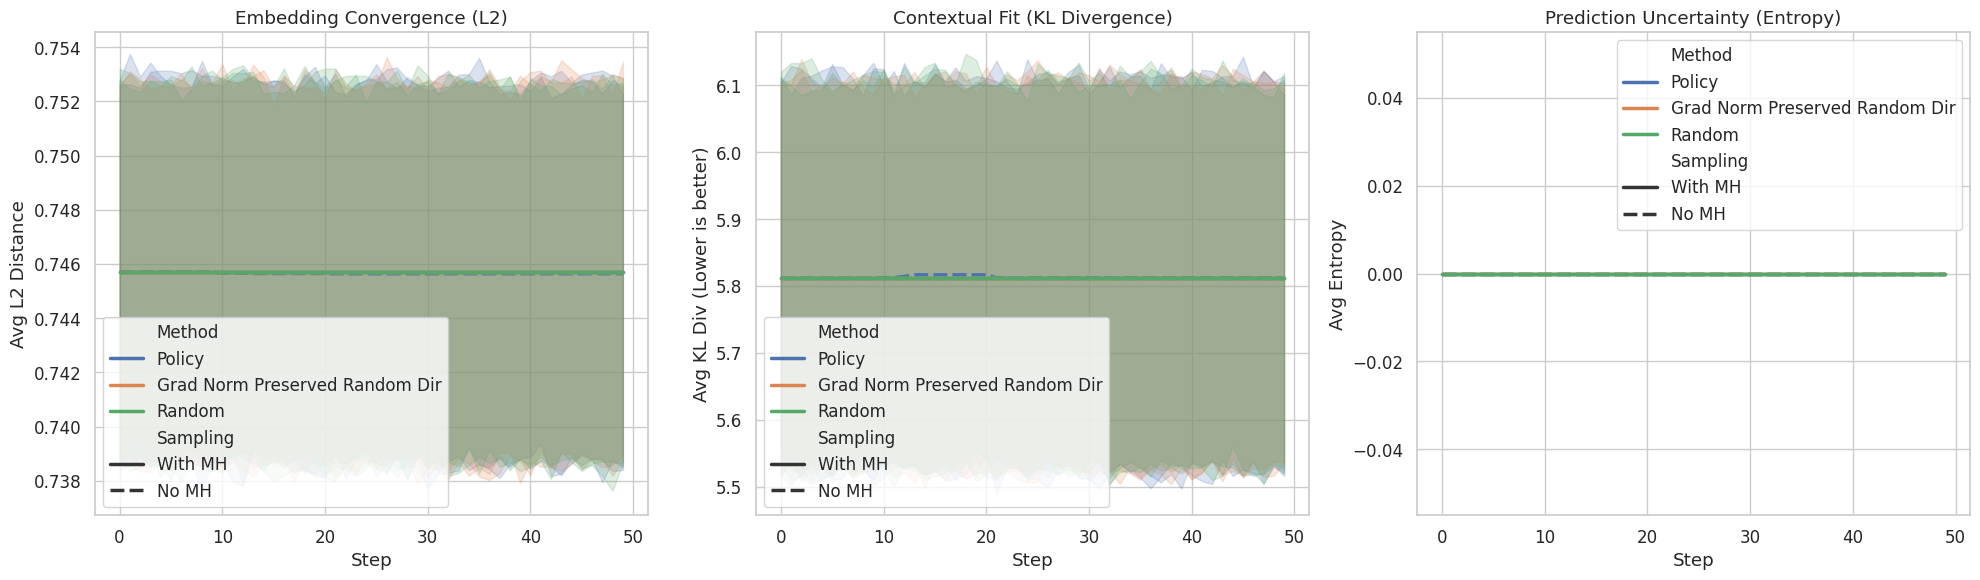

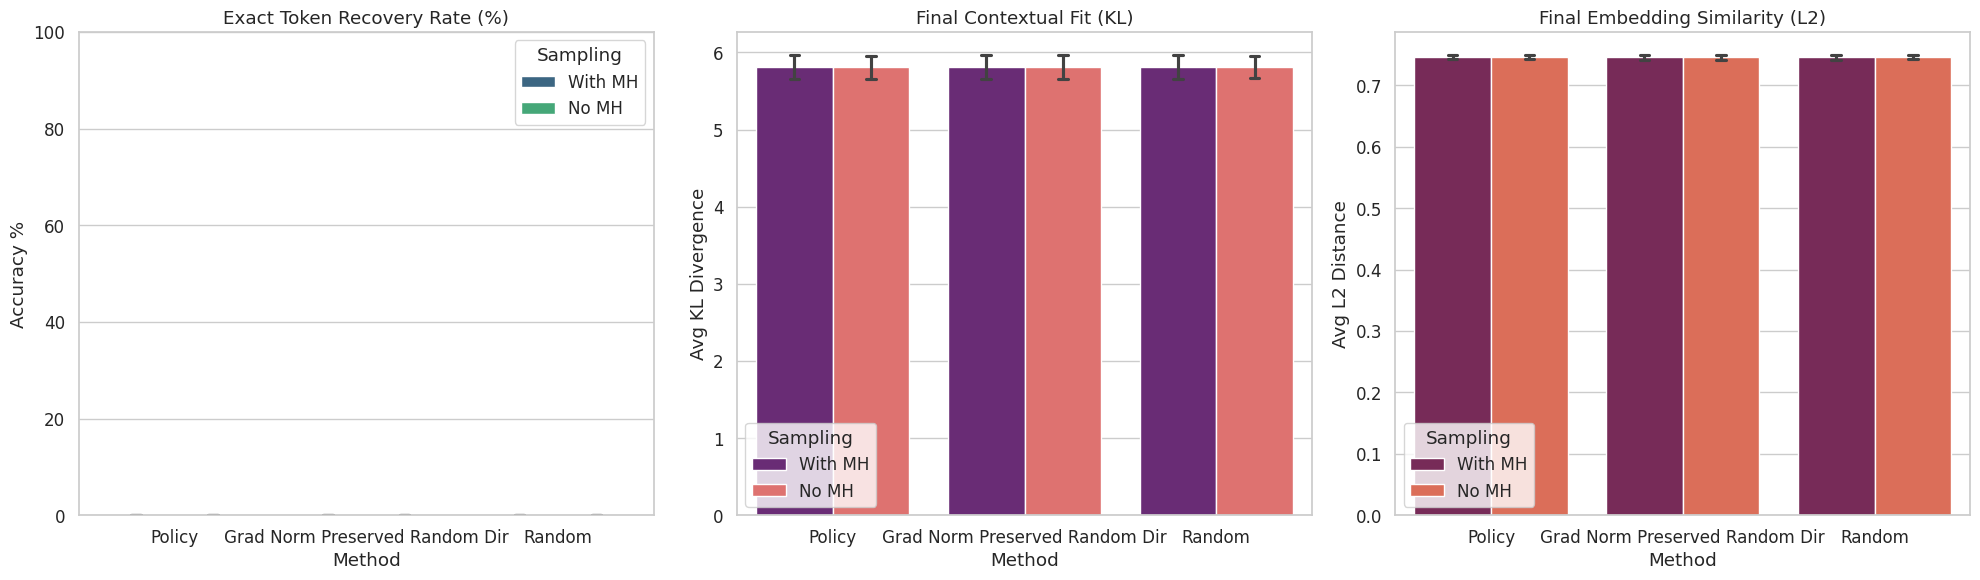

In [5]:



# 3. Preprocessing Summary Data (for Bar Charts)
summary_df = df.copy()
summary_df['Method'] = summary_df['method'].str.replace('_', ' ').str.title()
summary_df['Sampling'] = summary_df['mh_enabled'].map({True: "With MH", False: "No MH"})

# =============================================================================
# PLOT 1: Trajectory Dynamics (Line Plots)
# =============================================================================
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A. Average L2 Distance over steps
sns.lineplot(
    data=traj_df, x="Step", y="Avg L2 Distance", 
    hue="Method", style="Sampling", 
    ax=axes[0], linewidth=2.5
)
axes[0].set_title("Embedding Convergence (L2)")
axes[0].set_ylabel("Avg L2 Distance")

# B. Average KL Divergence over steps
sns.lineplot(
    data=traj_df, x="Step", y="Avg KL Divergence", 
    hue="Method", style="Sampling", 
    ax=axes[1], linewidth=2.5
)
axes[1].set_title("Contextual Fit (KL Divergence)")
axes[1].set_ylabel("Avg KL Div (Lower is better)")

# C. Entropy over steps (New metric for Multi-token)
sns.lineplot(
    data=traj_df, x="Step", y="Entropy", 
    hue="Method", style="Sampling", 
    ax=axes[2], linewidth=2.5
)
axes[2].set_title("Prediction Uncertainty (Entropy)")
axes[2].set_ylabel("Avg Entropy")

plt.tight_layout()
plt.show()

# =============================================================================
# PLOT 2: Final Performance Summary (Bar Charts)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A. Token Accuracy %
sns.barplot(
    data=summary_df, x="Method", y="accuracy_pct", hue="Sampling",
    ax=axes[0], palette="viridis", errorbar=('ci', 68), capsize=0.1
)
axes[0].set_title("Exact Token Recovery Rate (%)")
axes[0].set_ylabel("Accuracy %")
axes[0].set_ylim(0, 100)

# B. Final Avg KL
sns.barplot(
    data=summary_df, x="Method", y="avg_kl_div", hue="Sampling",
    ax=axes[1], palette="magma", errorbar=('ci', 68), capsize=0.1
)
axes[1].set_title("Final Contextual Fit (KL)")
axes[1].set_ylabel("Avg KL Divergence")

# C. Final Avg L2
sns.barplot(
    data=summary_df, x="Method", y="avg_l2_dist", hue="Sampling",
    ax=axes[2], palette="rocket", errorbar=('ci', 68), capsize=0.1
)
axes[2].set_title("Final Embedding Similarity (L2)")
axes[2].set_ylabel("Avg L2 Distance")

plt.tight_layout()
plt.show()

### Multiple Methods

In [6]:
# 1. Configuration
file_path = '../GradientInformation/experiment_results_cls_multi_oracle_False_samples_1000_date_2026-03-10.csv'  # Ensure this matches your filename

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Cannot find '{file_path}'. Please check the filename.")

df = pd.read_csv(file_path)
print(f"✅ Loaded {len(df)} experiment records.")

# 2. Data Parsing & Flattening
expanded_rows = []
summary_rows =[]

# Method name mapping for cleaner labels
method_map = {
    'policy': 'DLP Policy',
    'grad_norm_preserved_random_dir': 'Grad Norm Noisy',
    'random': 'Random Noise'
}

print("Parsing trajectories...")
for idx, row in df.iterrows():
    # Map method name
    method_name = method_map.get(row['method'], row['method'])
    mh_label = "With MH" if row['mh_enabled'] else "No MH"
    
    # Safely parse the trajectory string
    try:
        if isinstance(row['trajectory'], str):
            traj_list = ast.literal_eval(row['trajectory'])
        else:
            traj_list = row['trajectory']
    except Exception as e:
        print(f"Skipping sample {idx} due to parsing error: {e}")
        continue

    # Flatten trajectory for line plots
    for step_data in traj_list:
        expanded_rows.append({
            "Sample": row['sample_idx'],
            "Method": method_name,
            "Sampling": mh_label,
            "Step": step_data.get('step', 0),
            "Avg L2 Distance": step_data.get('avg_l2_distance', np.nan),
            "Avg KL Divergence": step_data.get('avg_kl_divergence', np.nan),
            "Entropy": step_data.get('entropy', np.nan)
        })
        
    # Append to summary data for bar charts
    summary_rows.append({
        "Sample": row['sample_idx'],
        "Method": method_name,
        "Sampling": mh_label,
        "Final Avg L2": row['avg_l2_dist'],
        "Final Avg KL": row['avg_kl_div'],
        "Accuracy %": row['accuracy_pct']
    })

traj_df = pd.DataFrame(expanded_rows)
summary_df = pd.DataFrame(summary_rows)

if traj_df.empty:
    raise ValueError("Parsed trajectory dataframe is empty. Check your CSV contents.")

print(f"✅ Successfully prepared {len(traj_df)} step records for plotting.")


✅ Loaded 1692 experiment records.
Parsing trajectories...
✅ Successfully prepared 84600 step records for plotting.


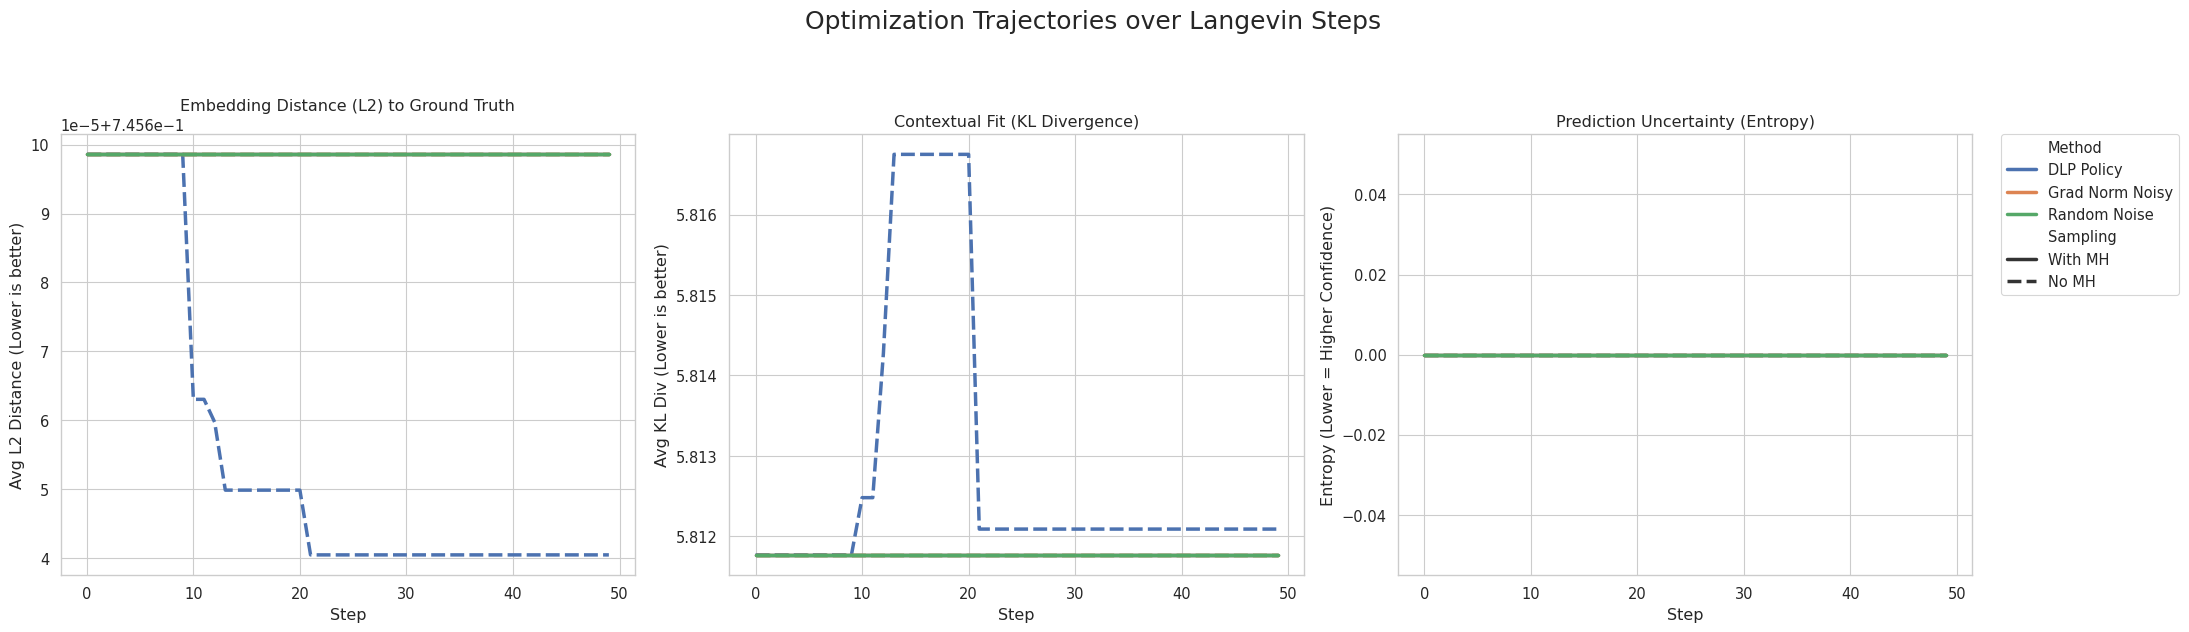

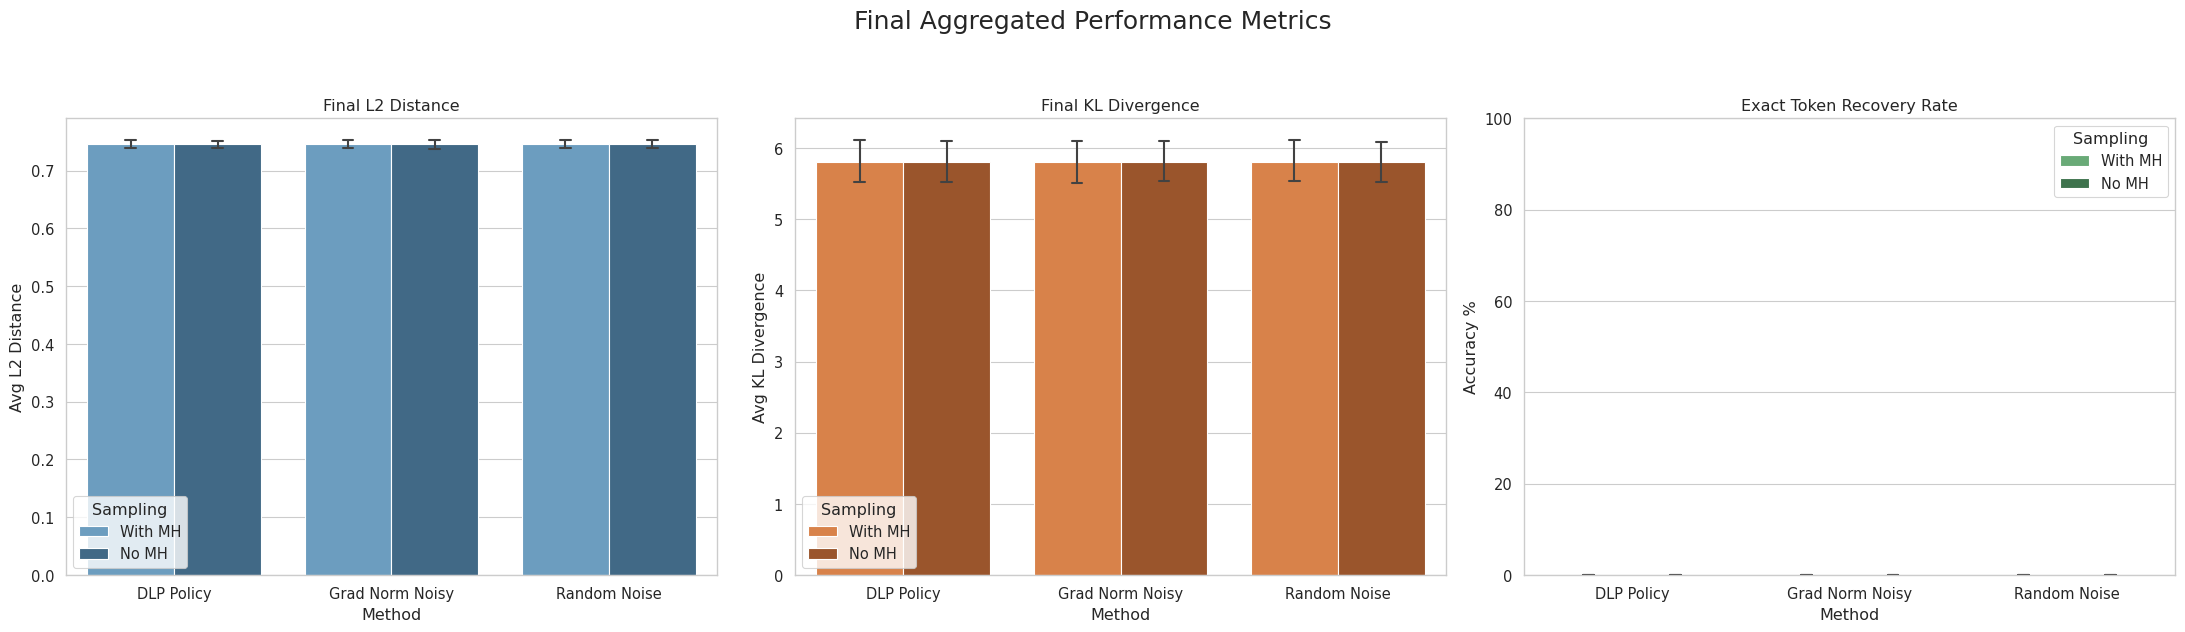

In [7]:

# Set visual style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("deep", 3) # 3 distinct colors for the 3 methods

# =============================================================================
# FIGURE 1: Trajectory Dynamics (Step-by-step)
# =============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(22, 6))
fig1.suptitle('Optimization Trajectories over Langevin Steps', fontsize=18, y=1.05)

# A. L2 Distance
sns.lineplot(
    data=traj_df, x="Step", y="Avg L2 Distance", 
    hue="Method", style="Sampling", palette=palette, 
    ax=axes1[0], linewidth=2.5, errorbar=None
)
axes1[0].set_title("Embedding Distance (L2) to Ground Truth")
axes1[0].set_ylabel("Avg L2 Distance (Lower is better)")

# B. KL Divergence
sns.lineplot(
    data=traj_df, x="Step", y="Avg KL Divergence", 
    hue="Method", style="Sampling", palette=palette, 
    ax=axes1[1], linewidth=2.5, errorbar=None
)
axes1[1].set_title("Contextual Fit (KL Divergence)")
axes1[1].set_ylabel("Avg KL Div (Lower is better)")

# C. Entropy
sns.lineplot(
    data=traj_df, x="Step", y="Entropy", 
    hue="Method", style="Sampling", palette=palette, 
    ax=axes1[2], linewidth=2.5, errorbar=None
)
axes1[2].set_title("Prediction Uncertainty (Entropy)")
axes1[2].set_ylabel("Entropy (Lower = Higher Confidence)")

# Clean up legends (only show on the last plot to save space)
axes1[0].get_legend().remove()
axes1[1].get_legend().remove()
axes1[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 2: Final Summary (Bar Charts)
# =============================================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(22, 6))
fig2.suptitle('Final Aggregated Performance Metrics', fontsize=18, y=1.05)

# A. Final L2 Distance
sns.barplot(
    data=summary_df, x="Method", y="Final Avg L2", hue="Sampling", 
    ax=axes2[0], palette="Blues_d", capsize=0.1, err_kws={'linewidth': 1.5}
)
axes2[0].set_title("Final L2 Distance")
axes2[0].set_ylabel("Avg L2 Distance")

# B. Final KL Divergence
sns.barplot(
    data=summary_df, x="Method", y="Final Avg KL", hue="Sampling", 
    ax=axes2[1], palette="Oranges_d", capsize=0.1, err_kws={'linewidth': 1.5}
)
axes2[1].set_title("Final KL Divergence")
axes2[1].set_ylabel("Avg KL Divergence")

# C. Accuracy
sns.barplot(
    data=summary_df, x="Method", y="Accuracy %", hue="Sampling", 
    ax=axes2[2], palette="Greens_d", capsize=0.1, err_kws={'linewidth': 1.5}
)
axes2[2].set_title("Exact Token Recovery Rate")
axes2[2].set_ylabel("Accuracy %")
axes2[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()